In [ ]:
from scipy.io import arff
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

data, meta = arff.loadarff("dataset")
df = pd.DataFrame(data)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print(df.shape)
print("=" * 10)
print(df.dtypes)
print("=" * 10)
print(df.info())

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64


In [ ]:
duplicates = df.duplicated().sum()
print("Количество полных дубликатов:", duplicates)
if duplicates:
    df = df.drop_duplicates().reset_index(drop=True)

Количество полных дубликатов: 1081


In [ ]:
class_counts = df["Class"].value_counts().sort_index()
class_ratio = df["Class"].value_counts(normalize=True).sort_index() * 100

print(class_counts)
print(class_ratio)

Class
0.0    283253
1.0       473
Name: count, dtype: int64
Class
0.0    99.83329
1.0     0.16671
Name: proportion, dtype: float64


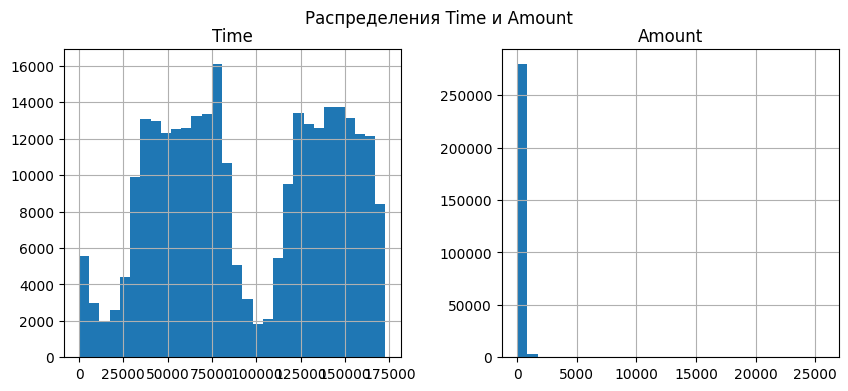

In [ ]:
df[["Time", "Amount"]].hist(figsize=(10, 4), bins=30)
plt.suptitle("Распределения Time и Amount")
plt.show()

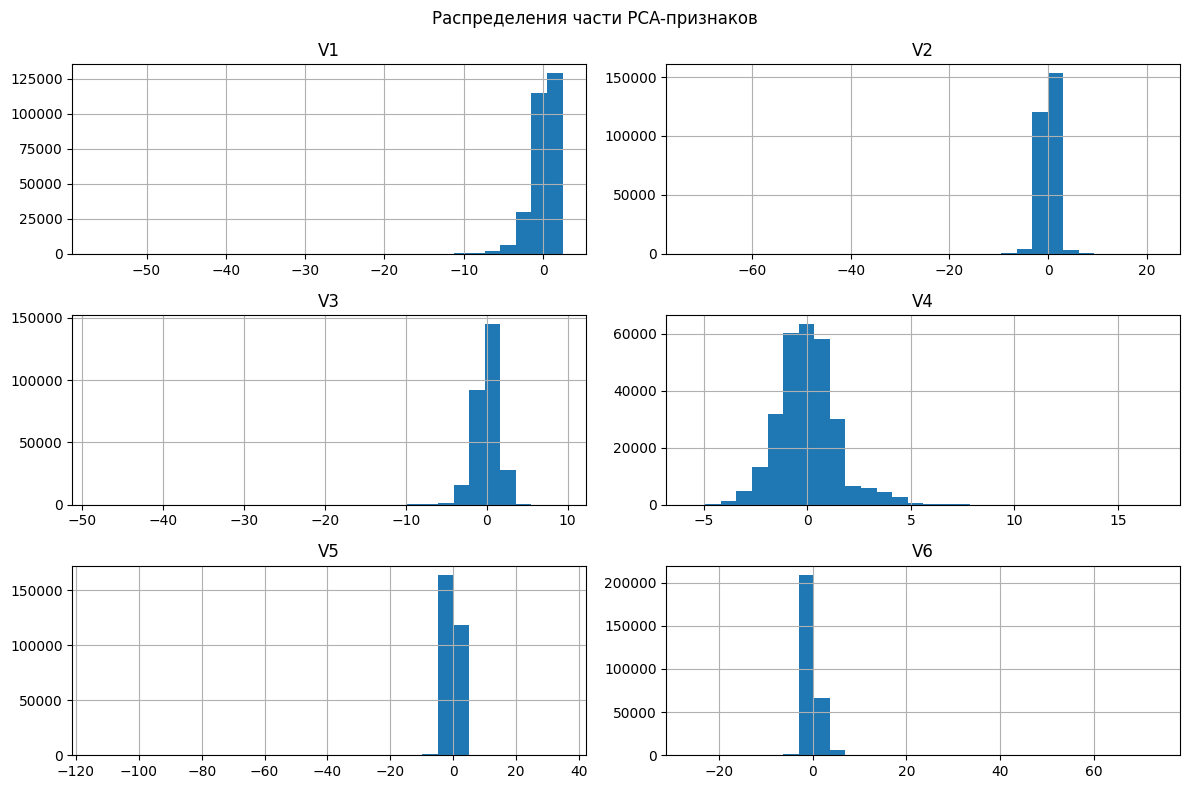

In [ ]:
cols = ["V1", "V2", "V3", "V4", "V5", "V6"]
df[cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Распределения части PCA-признаков")
plt.tight_layout()
plt.show()

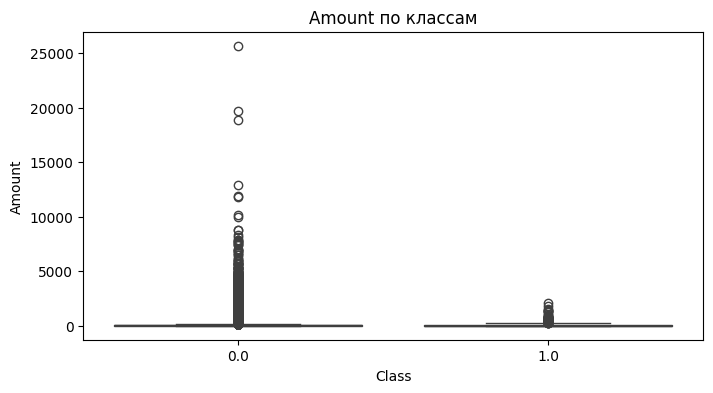

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Class", y="Amount")
plt.title("Amount по классам")
plt.show()

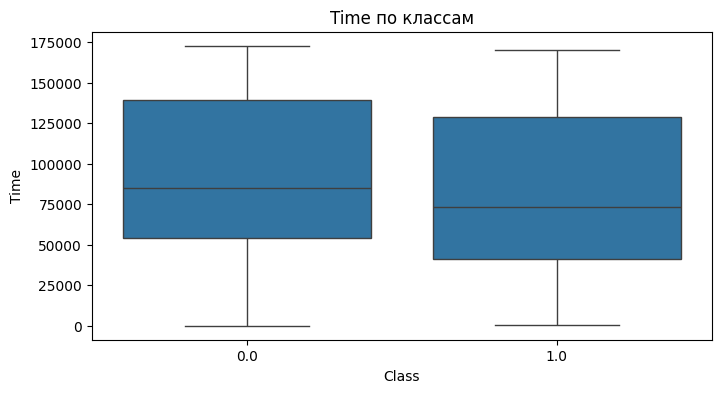

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Class", y="Time")
plt.title("Time по классам")
plt.show()

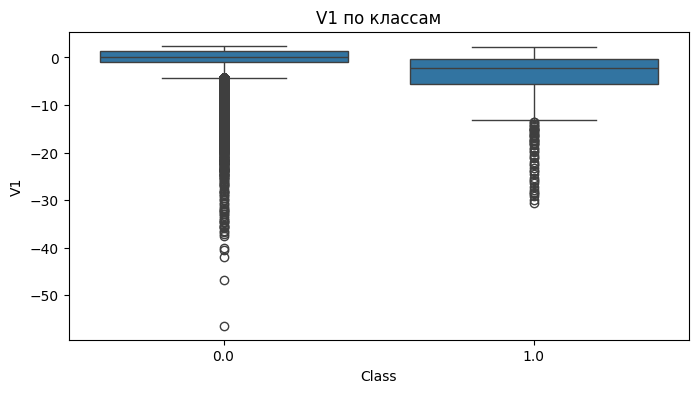

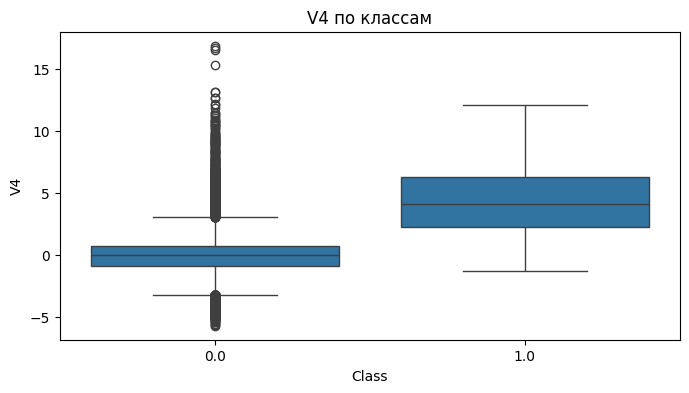

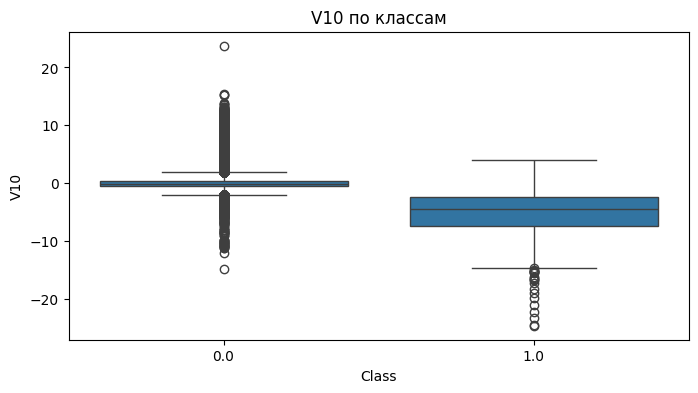

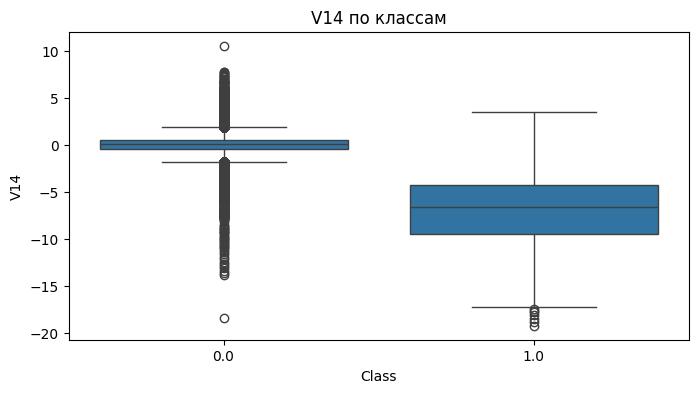

In [ ]:
for col in ["V1", "V4", "V10", "V14"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="Class", y=col)
    plt.title(f"{col} по классам")
    plt.show()

In [ ]:
corr_with_target = df.corr(numeric_only=True)["Class"].sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_target

,Class
Class,1.000000
V17,-0.313498
V14,-0.293375
V12,-0.250711
V10,-0.206971
V16,-0.187186
V3,-0.182322
V7,-0.172347
V11,0.149067
V4,0.129326


In [ ]:
corr_with_target.drop("Class").abs().sort_values(ascending=False).head(10)

,Class
V17,0.313498
V14,0.293375
V12,0.250711
V10,0.206971
V16,0.187186
V3,0.182322
V7,0.172347
V11,0.149067
V4,0.129326
V18,0.105340


In [ ]:
nunique = df.nunique().sort_values()
nunique.head(len(df.columns))

,0
Class,2
Amount,32767
Time,124592
V1,275663
V4,275663
V5,275663
V2,275663
V3,275663
V8,275663
V9,275663


Validation ROC-AUC: 0.9447
   feature  importance_mean  importance_std
4       V4         0.016317        0.004123
14     V14         0.009181        0.004677
17     V17         0.008488        0.005279
24     V24         0.007477        0.002552
5       V5         0.006141        0.002339
3       V3         0.006018        0.004271
15     V15         0.005091        0.001582
6       V6         0.004621        0.006891
29  Amount         0.004130        0.002376
28     V28         0.003803        0.002684
16     V16         0.003757        0.003508
8       V8         0.003603        0.002555
27     V27         0.003388        0.004088
18     V18         0.003307        0.003502
7       V7         0.002544        0.002421


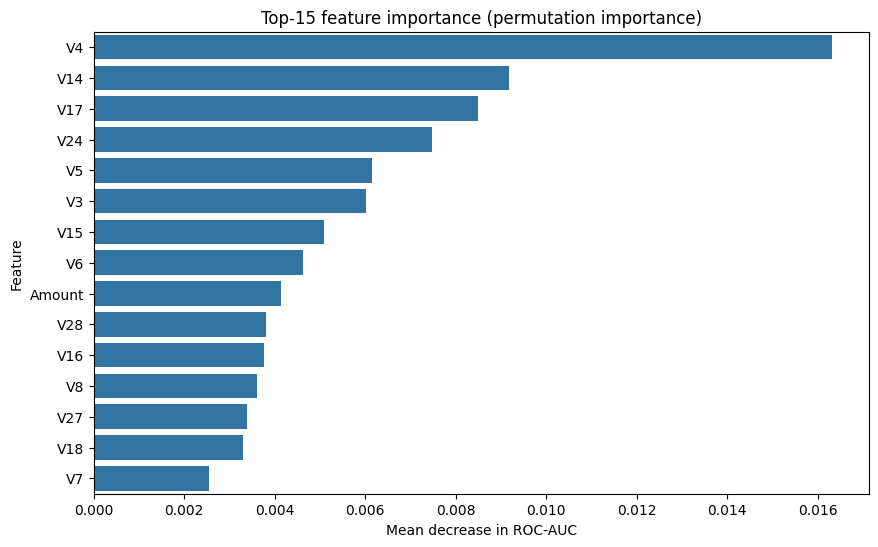

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

if df["Class"].dtype == "object":
    y = df["Class"].apply(lambda x: int(x.decode("utf-8")) if isinstance(x, bytes) else int(x))
else:
    y = df["Class"].astype(int)

X = df.drop(columns=["Class"]).copy()

# train / valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# простая базовая модель
model = RandomForestClassifier(
    n_estimators=200,
    random_state=123,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# качество baseline-модели
valid_proba = model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, valid_proba)
print(f"Validation ROC-AUC: {auc:.4f}")

# permutation importance
perm = permutation_importance(
    model,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=123,
    n_jobs=-1,
    scoring="roc_auc"
)

fi = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(fi.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi.head(15), x="importance_mean", y="feature")
plt.title("Top-15 feature importance (permutation importance)")
plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("Feature")
plt.show()